In [57]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast


In [58]:
experiment_dir = Path("/dcs/large/u1508153/misdro/newsvendor_1d")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")
results_df

,replication,mean_cost,var_cost,solution,dgp_time,likelihood_time,posterior_time,solve_time,algorithm,contamination,dgp,epsilon,lengthscale,num_likelihood_samples,num_observations,num_posterior_samples,num_replications,num_test_observations,posterior
uuid,,,,,,,,,,,,,,,,,,,
981b7be8-724d-408e-991c-5f56b84cffca,0,32.581618,674.766317,18.42,0.001115,0.007537,0.000161,294.030933,bayesian_dro,0.0,truncated_normal,0.01,-1.0,100,20,100,200,50,bayes
981b7be8-724d-408e-991c-5f56b84cffca,1,30.470314,640.593244,16.97,0.002127,0.010463,0.000361,269.048334,bayesian_dro,0.0,truncated_normal,0.01,-1.0,100,20,100,200,50,bayes
981b7be8-724d-408e-991c-5f56b84cffca,2,27.689672,441.323985,16.30,0.001618,0.012135,0.000231,261.583284,bayesian_dro,0.0,truncated_normal,0.01,-1.0,100,20,100,200,50,bayes
981b7be8-724d-408e-991c-5f56b84cffca,3,28.836681,556.633950,16.22,0.001557,0.012325,0.000249,256.066094,bayesian_dro,0.0,truncated_normal,0.01,-1.0,100,20,100,200,50,bayes
981b7be8-724d-408e-991c-5f56b84cffca,4,33.529120,245.012114,22.97,0.001634,0.012601,0.000247,334.323960,bayesian_dro,0.0,truncated_normal,0.01,-1.0,100,20,100,200,50,bayes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7fd8b6a9-9b67-4aec-9419-7bfda5ca9ef8,195,77.830965,671.207351,38.22,0.001382,0.012221,0.000228,169.716609,bayesian_dro,0.0,truncated_normal,1.00,-1.0,100,20,100,200,50,bayes
7fd8b6a9-9b67-4aec-9419-7bfda5ca9ef8,196,93.030184,472.504976,41.21,0.001381,0.011927,0.000218,166.780334,bayesian_dro,0.0,truncated_normal,1.00,-1.0,100,20,100,200,50,bayes
7fd8b6a9-9b67-4aec-9419-7bfda5ca9ef8,197,71.344742,575.059916,38.04,0.001363,0.012009,0.000223,163.077042,bayesian_dro,0.0,truncated_normal,1.00,-1.0,100,20,100,200,50,bayes


In [59]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "posterior"])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
})
df

mean_cost              \
                                                      mean         var   
algorithm    dgp              epsilon posterior                          
bayesian_dro truncated_normal 0.01    bayes      32.374657   20.012830   
                                      wll        32.336697   18.814326   
                              0.02    bayes      32.725680   20.895013   
                                      wll        32.721732   19.552479   
                              0.05    bayes      33.981051   26.130075   
                                      wll        34.079983   24.220975   
                              0.10    bayes      36.294686   37.960913   
                                      mmd        47.316492  113.590814   
                                      wll        36.573295   35.543690   
                              0.15    bayes      38.787073   50.710286   
                                      mmd        51.728648  144.336544   
                                      wll        39.240262   48.111015   
                              0.20    bayes      41.385744   64.246089   
                                      mmd        55.871757  174.078514   
                                      wll        41.996390   61.576472   
                              0.25    bayes      44.030607   78.253582   
                                      mmd        59.817827  202.959931   
                                      wll        44.782162   75.739769   
                              0.30    bayes      46.697896   92.460673   
                                      mmd        63.588567  226.629208   
                                      wll        47.601749   90.540531   
                              0.40    bayes      51.974819  120.728943   
                                      mmd        70.793983  268.731442   
                                      wll        53.167116  119.496863   
                              0.50    bayes      57.064640  148.019992   
                                      mmd        77.329468  297.611153   
                                      wll        58.447500  147.158840   
                              1.00    bayes      78.225302  228.010074   

                                                   var_cost posterior_time  \
                                                       mean           mean   
algorithm    dgp              epsilon posterior                              
bayesian_dro truncated_normal 0.01    bayes      624.603309       0.000233   
                                      wll        613.212626       0.016782   
                              0.02    bayes      580.450277       0.000227   
                                      wll        570.509090       0.017878   
                              0.05    bayes      511.345548       0.000229   
                                      wll        504.870417       0.016959   
                              0.10    bayes      466.033242       0.000229   
                                      mmd        462.501146      73.776551   
                                      wll        461.605950       0.016875   
                              0.15    bayes      449.307932       0.000231   
                                      mmd        472.337061      72.306443   
                                      wll        446.523137       0.017193   
                              0.20    bayes      445.652402       0.000239   
                                      mmd        482.913560      71.951894   
                                      wll        444.596491       0.016968   
                              0.25    bayes      448.571527       0.000237   
                                      mmd        494.630252      72.209441   
                                      wll        449.425830       0.016847   
                              0.30    bayes      455.047287       0.000229   
                                      

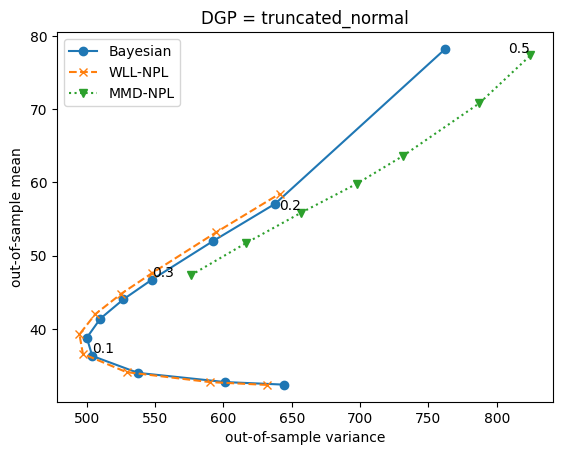

In [64]:
# parameters to filter by:
algorithm = "bayesian_dro"
# dgp = "contaminated_exp"
dgp = "truncated_normal"

# get a dataframe for each posterior
bayes_df = df.loc[algorithm, dgp, :, "bayes"]
wll_df = df.loc[algorithm, dgp, :, "wll"]
mmd_df = df.loc[algorithm, dgp, :, "mmd"]

# mean of variances + variance of means
bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
wll_bootstrap_var = wll_df["var_cost"]["mean"] + wll_df["mean_cost"]["var"]
mmd_bootstrap_var = mmd_df["var_cost"]["mean"] + mmd_df["mean_cost"]["var"]

plt.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="Bayesian")
plt.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
plt.plot(mmd_bootstrap_var, mmd_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

plt.title(f"DGP = {dgp}")
plt.legend()
plt.xlabel("out-of-sample variance")
plt.ylabel("out-of-sample mean")
for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
    if i % 4 == 0:
        plt.text(bayes_bootstrap_var[epsilon], bayes_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
    if (i+2) % 4 == 0:
        plt.text(mmd_bootstrap_var[epsilon], mmd_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

Text(0, 0.5, 'Solve time (s)')

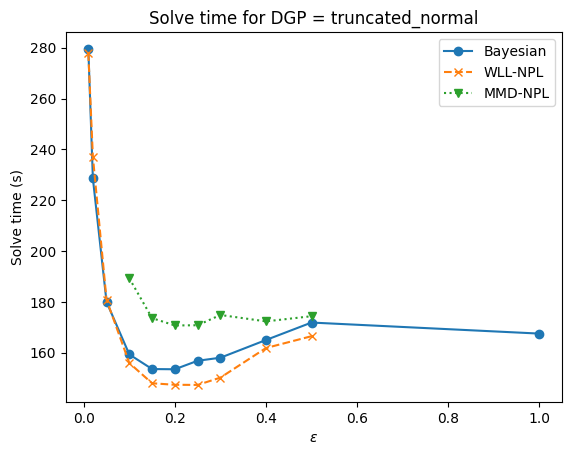

In [61]:
plt.plot(bayes_df.index, bayes_df["solve_time"]["mean"], marker='o', linestyle="solid", label="Bayesian")
plt.plot(wll_df.index, wll_df["solve_time"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
plt.plot(mmd_df.index, mmd_df["solve_time"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")
plt.title(f"Solve time for DGP = {dgp}")
plt.legend()
plt.xlabel("$\epsilon$")
plt.ylabel("Solve time (s)")

In [62]:
idx = pd.IndexSlice
df.loc[idx[algorithm, dgp, 0.1:, "bayes":"mmd"], idx["mean_cost", :]] 

mean_cost            
                                                      mean         var
algorithm    dgp              epsilon posterior                       
bayesian_dro truncated_normal 0.10    bayes      36.294686   37.960913
                                      mmd        47.316492  113.590814
                              0.15    bayes      38.787073   50.710286
                                      mmd        51.728648  144.336544
                              0.20    bayes      41.385744   64.246089
                                      mmd        55.871757  174.078514
                              0.25    bayes      44.030607   78.253582
                                      mmd        59.817827  202.959931
                              0.30    bayes      46.697896   92.460673
                                      mmd        63.588567  226.629208
                              0.40    bayes      51.974819  120.728943
                                      mmd        70.793983  268.731442
                              0.50    bayes      57.064640  148.019992
                                      mmd        77.329468  297.611153
                              1.00    bayes      78.225302  228.010074